# Augmented Grapevine Disease Classification

In [1]:
import cv2 
import pandas as pd
import numpy as np
import os
from keras.models import Sequential
from keras.layers import Conv2D,Dense,Flatten,Input,MaxPooling2D,Dropout,BatchNormalization,Reshape
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import warnings
warnings.filterwarnings("ignore")

## Exploraty Data Analysis and Data Preprocessing

In [3]:
labels=["Black Rot","ESCA","Leaf Blight","Healthy"]
img_path="Final Training Data/"

In [4]:
img_list=[]
label_list=[]
for label in labels:
    for img_file in os.listdir(img_path+label):
        img_list.append(os.path.join(img_path,label,img_file))
        label_list.append(label)

In [5]:
df=pd.DataFrame({"img":img_list,"label":label_list})

In [6]:
df

,img,label
0,Final Training Data/Black Rot\00090b0f-c140-4e...,Black Rot
1,Final Training Data/Black Rot\003d09ef-e16c-4e...,Black Rot
2,Final Training Data/Black Rot\004175d8-dc74-42...,Black Rot
3,Final Training Data/Black Rot\004175d8-dc74-42...,Black Rot
4,Final Training Data/Black Rot\006efc68-9e46-41...,Black Rot
...,...,...
11995,Final Training Data/Healthy\_992_9227676.png,Healthy
11996,Final Training Data/Healthy\_992_9388542.png,Healthy
11997,Final Training Data/Healthy\_992_9431105.png,Healthy
11998,Final Training Data/Healthy\_992_9492333.png,Healthy


In [7]:
tf.keras.backend.clear_session()
train_ds = tf.keras.utils.image_dataset_from_directory(
    img_path,
    validation_split=0.2,       
    subset="training",
    seed=123,
    image_size=(128, 128),     
    batch_size=64
)


Found 12000 files belonging to 4 classes.
Using 9600 files for training.


In [8]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    img_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=64
)

Found 12000 files belonging to 4 classes.
Using 2400 files for validation.


In [9]:
normalization_layer = layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Model Training and Testing

In [10]:
num_classes = 4

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='softmax')
])



In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(train_ds,validation_data=val_ds,epochs=5,verbose=1)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 52s 261ms/step - accuracy: 0.7599 - loss: 0.6020 - val_accuracy: 0.8804 - val_loss: 0.3229
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 37s 246ms/step - accuracy: 0.9073 - loss: 0.2581 - val_accuracy: 0.9275 - val_loss: 0.2048
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 36s 238ms/step - accuracy: 0.9404 - loss: 0.1646 - val_accuracy: 0.9425 - val_loss: 0.1527
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 43s 254ms/step - accuracy: 0.9491 - loss: 0.1400 - val_accuracy: 0.9308 - val_loss: 0.1693
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 39s 243ms/step - accuracy: 0.9691 - loss: 0.0918 - val_accuracy: 0.9483 - val_loss: 0.1265


## Data Visualization

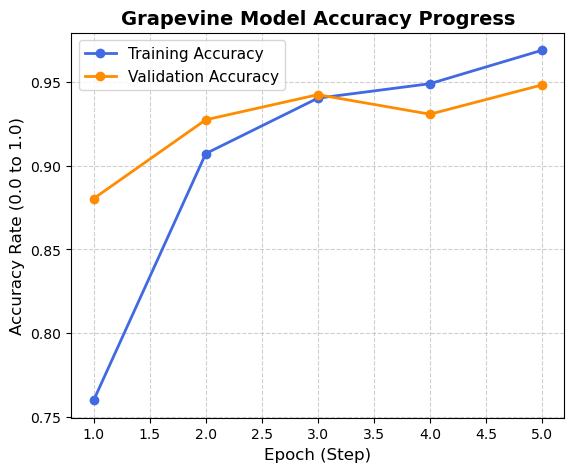

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', color='royalblue', linewidth=2, label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'o-', color='darkorange', linewidth=2, label='Validation Accuracy')
plt.title('Grapevine Model Accuracy Progress', fontsize=14, fontweight='bold')
plt.xlabel('Epoch (Step)', fontsize=12)
plt.ylabel('Accuracy Rate (0.0 to 1.0)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

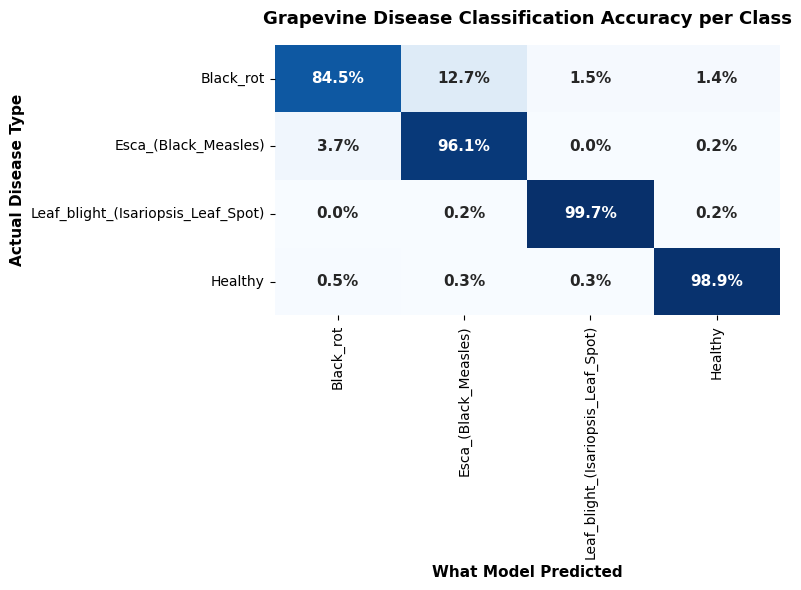

In [14]:
class_names = ['Black_rot', 'Esca_(Black_Measles)', 'Leaf_blight_(Isariopsis_Leaf_Spot)', 'Healthy']

y_true = np.concatenate([y for x, y in val_ds], axis=0)
predictions = model.predict(val_ds, verbose=0)
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='.1%',           
    cmap='Blues', 
    cbar=False,
    xticklabels=class_names, 
    yticklabels=class_names,
    annot_kws={"size": 11, "weight": "bold"}
)

plt.title('Grapevine Disease Classification Accuracy per Class', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('What Model Predicted', fontsize=11, fontweight='bold')
plt.ylabel('Actual Disease Type', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
model.save("grapevine_model.keras")

# Transfer Learning

In [17]:
from tensorflow.keras.applications import MobileNetV2


dataset_dir = 'Final Training Data'  
img_shape = (128, 128, 3)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=img_shape
)
base_model.trainable = False  
model_grape_tl = models.Sequential([
    layers.Rescaling(1./255, input_shape=img_shape),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),  
    layers.Dense(num_classes, activation='softmax')
])

model_grape_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



Found 12000 files belonging to 4 classes.
Using 9600 files for training.
Found 12000 files belonging to 4 classes.
Using 2400 files for validation.


In [18]:
history_grape_tl = model_grape_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 153s 442ms/step - accuracy: 0.9367 - loss: 0.1646 - val_accuracy: 0.9675 - val_loss: 0.0808
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 128s 427ms/step - accuracy: 0.9780 - loss: 0.0587 - val_accuracy: 0.9775 - val_loss: 0.0572
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 157s 478ms/step - accuracy: 0.9855 - loss: 0.0454 - val_accuracy: 0.9871 - val_loss: 0.0347
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 185s 423ms/step - accuracy: 0.9877 - loss: 0.0317 - val_accuracy: 0.9796 - val_loss: 0.0545
Epoch 5/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 143s 426ms/step - accuracy: 0.9905 - loss: 0.0275 - val_accuracy: 0.9925 - val_loss: 0.0255
